# Лабораторная работа 15

Тема: **Transformer-энкодер для классификации тональности текстов**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание архитектуры Transformer (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. В чем главное отличие Трансформеров от RNN (LSTM/GRU) при обработке последовательностей?
2. Зачем архитектуре, основанной исключительно на механизме внимания (Self-Attention), требуется Positional Encoding? Что будет, если его убрать?
3. Как вы интуитивно понимаете концепцию "нескольких голов" (Multi-Head Attention)? Зачем нужна разбивка на несколько независимых проекций?

Пишите своими словами, как если бы объясняли задачу одногруппнику.

In [ ]:
intro_text = """
1. RNN обрабатывает токены последовательно - слово за словом, передавая
скрытое состояние дальше. Из-за этого информация о далёких словах может
теряться, и нельзя распараллелить вычисления. Трансформер смотрит на все
слова сразу через механизм внимания - каждое слово сразу взаимодействует
со всеми остальными независимо от расстояния между ними.

2. Без Positional Encoding трансформер не знает порядок слов - "кошка съела
мышку" и "мышка съела кошку" будут одинаковыми для модели. PE добавляет
к каждому токену информацию о его позиции в последовательности через sin/cos
функции. Без него модель видит просто набор слов без порядка - bag of words.

3. Multi-Head Attention - это как смотреть на предложение с разных точек
зрения одновременно. Одна голова может следить за грамматическими связями,
другая - за смысловыми, третья - за тональностью. Если была бы одна голова,
она усредняла бы все эти аспекты в одно представление и теряла детали.
Несколько независимых проекций позволяют модели улавливать разные типы
зависимостей между словами параллельно.
"""
print(intro_text)


1. RNN обрабатывает токены последовательно - слово за словом, передавая
скрытое состояние дальше. Из-за этого информация о далёких словах может
теряться, и нельзя распараллелить вычисления. Трансформер смотрит на все
слова сразу через механизм внимания - каждое слово сразу взаимодействует
со всеми остальными независимо от расстояния между ними.

2. Без Positional Encoding трансформер не знает порядок слов - "кошка съела
мышку" и "мышка съела кошку" будут одинаковыми для модели. PE добавляет
к каждому токену информацию о его позиции в последовательности через sin/cos
функции. Без него модель видит просто набор слов без порядка - bag of words.

3. Multi-Head Attention - это как смотреть на предложение с разных точек
зрения одновременно. Одна голова может следить за грамматическими связями,
другая - за смысловыми, третья - за тональностью. Если была бы одна голова,
она усредняла бы все эти аспекты в одно представление и теряла детали.
Несколько независимых проекций позволяют модели улавл

## 2. Импорт, настройки и данные (IMDB)

Для работы потребуется библиотека `datasets`.
Если она не установлена, выполните `%pip install datasets`


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, concatenate_datasets
from collections import Counter
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

MY_SEED = 31  # 42 - 31
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Загружаем датасет отзывов на фильмы
dataset = load_dataset("imdb")

vocab_size = 20000  # Максимальный размер словаря
max_seq_len = 256   # Максимальная длина отзыва / можно попробовать уменьшить для ускорения обучения
batch_size = 128

# 1. Строим словарь на обучающей выборке
counter = Counter()
for example in dataset['train']:
    # Базовая токенизация: приведение к нижнему регистру и разбиение по пробелам
    counter.update(example['text'].lower().split())

# 2. Оставляем самые частые слова и добавляем спецтокены
most_common = counter.most_common(vocab_size - 2)
vocab = {word: i + 2 for i, (word, _) in enumerate(most_common)}
vocab['<pad>'] = 0
vocab['<unk>'] = 1

PAD_IDX = 0
UNK_IDX = 1

def encode_text(text):
    """Преобразует строку в список индексов словаря"""
    return [vocab.get(word, UNK_IDX) for word in text.lower().split()]

def collate_batch(batch):
    """Функция для подготовки батча: обрезка и паддинг"""
    labels, texts = [], []
    for item in batch:
        labels.append(item['label'])
        encoded = torch.tensor(encode_text(item['text']), dtype=torch.int64)

        # Обрезаем слишком длинные отзывы
        if encoded.size(0) > max_seq_len:
            encoded = encoded[:max_seq_len]
        texts.append(encoded)

    labels = torch.tensor(labels, dtype=torch.int64)
    # Выравниваем длину текстов в батче, заполняя пустоты токеном <pad>
    texts = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)

    return texts, labels

# Создаем загрузчики данных. Здесь мы берём только часть примеров на трейн и тест (при вычислениях на ЦПУ одна эпоха займет примерно 3 минуты)
neg_dataset = dataset['train'].filter(lambda x: x['label'] == 0).select(range(2000))
pos_dataset = dataset['train'].filter(lambda x: x['label'] == 1).select(range(2000))

train_subset = concatenate_datasets([neg_dataset, pos_dataset]).shuffle(seed=MY_SEED)
test_subset = dataset['test'].shuffle(seed=MY_SEED).select(range(1000))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

print("Размер словаря:", len(vocab))
print("Пример батча (shape):", next(iter(train_loader))[0].shape)

Устройство: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Размер словаря: 20000
Пример батча (shape): torch.Size([128, 256])


### Мини‑комментарий по предобработке данных

Кратко (3-5 предложений) опишите:

- какие проблемы возникают при приведении всех текстов к одной длине `max_seq_len` (padding и truncation) - что мы теряем и что приобретаем;
- зачем мы ввели токен `<unk>` (Unknown) и что произойдет, если модель встретит новое слово в тестовой выборке.


In [ ]:
data_comment = """
При обрезке до max_seq_len=256 теряем хвост длинных отзывов - а концовка
часто содержит итоговую оценку ("в целом фильм понравился"). Padding
добавляет нули в короткие отзывы - это балласт который модель должна научиться
игнорировать. Зато все тексты одного размера - можно собирать в батчи.

unk нужен для слов которых нет в словаре - редкие слова, опечатки, имена
собственные. Если в тестовом отзыве встретится слово не из топ-20000, оно
заменится на unk. Модель не потеряет позицию токена, но потеряет его смысл.
Если таких слов много - качество предсказания падает.
"""
print(data_comment)


При обрезке до max_seq_len=256 теряем хвост длинных отзывов - а концовка
часто содержит итоговую оценку ("в целом фильм понравился"). Padding
добавляет нули в короткие отзывы - это балласт который модель должна научиться
игнорировать. Зато все тексты одного размера - можно собирать в батчи.

unk нужен для слов которых нет в словаре - редкие слова, опечатки, имена
собственные. Если в тестовом отзыве встретится слово не из топ-20000, оно
заменится на unk. Модель не потеряет позицию токена, но потеряет его смысл.
Если таких слов много - качество предсказания падает.



## 3. Архитектура: Positional Encoding и Transformer


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x

class TextTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Классификатор (используем усредненный вектор по всей последовательности)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, src, src_key_padding_mask=None):
        # src shape: (batch_size, seq_len)
        embedded = self.embedding(src) * math.sqrt(d_model)
        embedded = self.pos_encoder(embedded)

        # output shape: (batch_size, seq_len, d_model)
        output = self.transformer_encoder(embedded, src_key_padding_mask=src_key_padding_mask)

        # Пулинг: берем среднее представление (только по реальным токенам, игнорируя PAD)
        # Для упрощения кода усредняем по всем выходам, но в продвинутых версиях нужно учитывать маску и при пулинге.
        pooled = output.mean(dim=1)

        return self.fc(pooled)

d_model = 64 # это можно менять
nhead = 4
num_layers = 3 # и это можно
num_classes = 2 # бинарная классификация (позитив/негатив)

model = TextTransformer(len(vocab), d_model, nhead, num_layers, num_classes).to(device)
print(model)

TextTransformer(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:

- зачем эмбеддинги умножаются на `math.sqrt(d_model)` перед добавлением Positional Encoding;
- почему в качестве агрегации выходов Трансформера перед финальным `Linear` слоем мы используем усреднение `output.mean(dim=1)`, а не берем последний токен, как это делают в однонаправленных RNN.

In [ ]:
arch_comment = """
Эмбеддинги умножаются на sqrt(d_model) чтобы их масштаб был сопоставим с
масштабом Positional Encoding. Без этого PE мог бы доминировать над смысловой
информацией из эмбеддингов - модель обращала бы больше внимания на позицию
токена чем на его смысл.

Усреднение output.mean(dim=1) берёт информацию со всех позиций одновременно -
это логично для классификации тональности, где важен весь отзыв целиком, а не
только последнее слово. В RNN последний токен содержит накопленный контекст
всей последовательности - это его смысл. В трансформере все токены обработаны
параллельно и нет "итогового" токена, поэтому усреднение даёт более полное
представление о всём тексте.
"""
print(arch_comment)


Эмбеддинги умножаются на sqrt(d_model) чтобы их масштаб был сопоставим с
масштабом Positional Encoding. Без этого PE мог бы доминировать над смысловой
информацией из эмбеддингов - модель обращала бы больше внимания на позицию
токена чем на его смысл.

Усреднение output.mean(dim=1) берёт информацию со всех позиций одновременно -
это логично для классификации тональности, где важен весь отзыв целиком, а не
только последнее слово. В RNN последний токен содержит накопленный контекст
всей последовательности - это его смысл. В трансформере все токены обработаны
параллельно и нет "итогового" токена, поэтому усреднение даёт более полное
представление о всём тексте.



## 4. Оптимизатор и функция потерь


In [ ]:
criterion = nn.CrossEntropyLoss()
lr = 3e-4
opt = torch.optim.Adam(model.parameters(), lr=lr)

## 5. Цикл обучения Трансформера

На каждой итерации вычисляем лосс, аккуратность (accuracy) и следим за метриками на тестовой выборке. Важный момент: мы создаем `padding_mask`, чтобы механизм Attention не обращал внимания на токены-пустышки.

In [ ]:
def train_transformer(num_epochs):
    train_loss_hist, test_loss_hist = [], []
    train_acc_hist, test_acc_hist = [], []

    for epoch in range(1, num_epochs + 1):
        # --- Обучение ---
        model.train()
        epoch_loss, epoch_correct, total_samples = 0.0, 0, 0

        for x, y in tqdm(train_loader, desc=f"Обучение, Эпоха {epoch}/{num_epochs}"):
            x, y = x.to(device), y.to(device)

            # Маска для Attention: True там, где токен является паддингом
            mask = (x == PAD_IDX).to(device)

            opt.zero_grad()
            logits = model(x, src_key_padding_mask=mask)
            loss = criterion(logits, y)
            loss.backward()

            # Ограничение (clipping) градиентов для стабилизации обучения
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            epoch_loss += loss.item()
            preds = logits.argmax(dim=-1)
            epoch_correct += (preds == y).sum().item()
            total_samples += y.size(0)

        train_loss_hist.append(epoch_loss / len(train_loader))
        train_acc_hist.append(epoch_correct / total_samples)

        # --- Валидация ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                mask = (x == PAD_IDX).to(device)
                logits = model(x, src_key_padding_mask=mask)
                loss = criterion(logits, y)

                val_loss += loss.item()
                val_correct += (logits.argmax(dim=-1) == y).sum().item()
                val_total += y.size(0)

        test_loss_hist.append(val_loss / len(test_loader))
        test_acc_hist.append(val_correct / val_total)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"Train Loss: {train_loss_hist[-1]:.4f}, Acc: {train_acc_hist[-1]:.4f} | "
              f"Test Loss: {test_loss_hist[-1]:.4f}, Acc: {test_acc_hist[-1]:.4f}")

    return train_loss_hist, test_loss_hist, train_acc_hist, test_acc_hist

# Для тестов можно поставить 3-5 эпох, для полного обучения - 10-15
num_epochs = 4
train_loss, test_loss, train_acc, test_acc = train_transformer(num_epochs)

Обучение, Эпоха 1/4: 100%|██████████| 32/32 [05:03<00:00,  9.49s/it]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Эпоха 1/4 | Train Loss: 0.6803, Acc: 0.5657 | Test Loss: 0.6767, Acc: 0.6050


Обучение, Эпоха 2/4: 100%|██████████| 32/32 [04:53<00:00,  9.18s/it]


Эпоха 2/4 | Train Loss: 0.6525, Acc: 0.6058 | Test Loss: 0.6642, Acc: 0.6210


Обучение, Эпоха 3/4: 100%|██████████| 32/32 [05:01<00:00,  9.44s/it]


Эпоха 3/4 | Train Loss: 0.5924, Acc: 0.6960 | Test Loss: 0.6247, Acc: 0.6650


Обучение, Эпоха 4/4: 100%|██████████| 32/32 [04:52<00:00,  9.15s/it]


Эпоха 4/4 | Train Loss: 0.5195, Acc: 0.7428 | Test Loss: 0.6060, Acc: 0.6750


### Анализ кривых лоссов и метрик

Опишите:

- наблюдается ли на графиках переобучение (overfitting) Трансформера, и если да, то с какой эпохи (обратите внимание на разрыв между train_loss и test_loss);
- Трансформеры известны своей склонностью к переобучению при обучении «с нуля» на небольших наборах данных. Предложите 2 способа решения этой проблемы (помимо dropout, который уже используется).

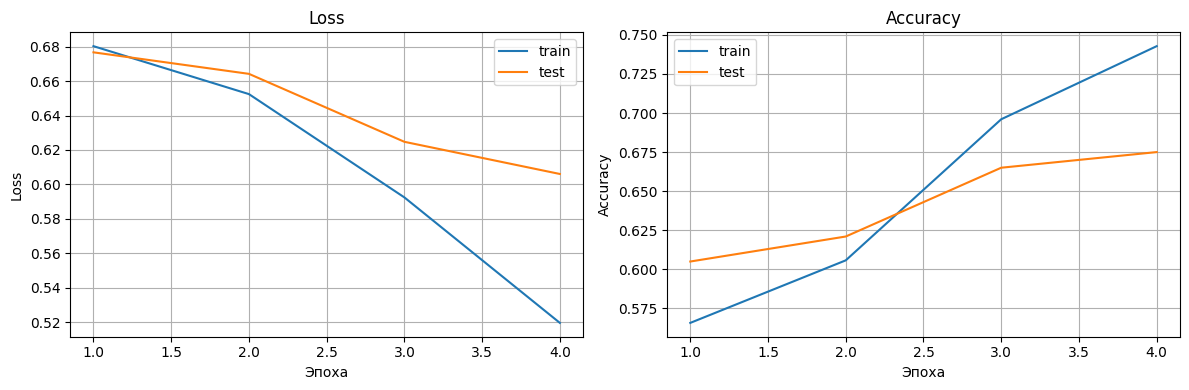

In [ ]:
epochs_arr = np.arange(1, num_epochs + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_arr, train_loss, label="train")
plt.plot(epochs_arr, test_loss, label="test")
plt.xlabel("Эпоха"); plt.ylabel("Loss")
plt.title("Loss"); plt.grid(True); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs_arr, train_acc, label="train")
plt.plot(epochs_arr, test_acc, label="test")
plt.xlabel("Эпоха"); plt.ylabel("Accuracy")
plt.title("Accuracy"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
loss_comment = """
На графике видно начало переобучения начиная примерно с 3-й эпохи - train_loss
падает резко (0.59 на 3-й, 0.52 на 4-й), а test_loss снижается медленнее
(0.62 и 0.61). Разрыв между train_acc=0.743 и test_acc=0.675 к 4-й эпохе
составляет 0.068 - модель начинает подстраиваться под train.

До 2-й эпохи кривые шли почти вместе - модель ещё не переобучалась.
С 3-й эпохи train пошёл вниз значительно быстрее test - классический признак.

Точность 0.675 невысокая - это объясняется малым датасетом (4000 примеров)
и небольшим числом эпох. Трансформер с нуля на таком объёме учится плохо.

Два способа борьбы с переобучением помимо dropout:
1. Transfer learning - взять предобученный BERT и дообучить только
   классификатор. Он уже знает язык, нужно намного меньше данных.
2. Label smoothing - вместо жёстких меток 0/1 использовать 0.1/0.9,
   модель не становится слишком уверенной и лучше обобщается.
"""
print(loss_comment)


На графике видно начало переобучения начиная примерно с 3-й эпохи - train_loss
падает резко (0.59 на 3-й, 0.52 на 4-й), а test_loss снижается медленнее
(0.62 и 0.61). Разрыв между train_acc=0.743 и test_acc=0.675 к 4-й эпохе
составляет 0.068 - модель начинает подстраиваться под train.

До 2-й эпохи кривые шли почти вместе - модель ещё не переобучалась.
С 3-й эпохи train пошёл вниз значительно быстрее test - классический признак.

Точность 0.675 невысокая - это объясняется малым датасетом (4000 примеров)
и небольшим числом эпох. Трансформер с нуля на таком объёме учится плохо.

Два способа борьбы с переобучением помимо dropout:
1. Transfer learning - взять предобученный BERT и дообучить только
   классификатор. Он уже знает язык, нужно намного меньше данных.
2. Label smoothing - вместо жёстких меток 0/1 использовать 0.1/0.9,
   модель не становится слишком уверенной и лучше обобщается.



## 7. Инференс: проверка модели на собственных текстах

Посмотрим, как модель классифицирует тексты, написанные вами.

In [ ]:
def predict_sentiment(text):
    model.eval()
    encoded = torch.tensor([encode_text(text)], dtype=torch.int64).to(device)
    mask = (encoded == PAD_IDX).to(device)

    with torch.no_grad():
        logits = model(encoded, src_key_padding_mask=mask)
        prob = torch.softmax(logits, dim=-1)[0]

    pred_class = prob.argmax().item()
    label = "Positive" if pred_class == 1 else "Negative"
    print(f"Текст: {text}\nОценка: {label} (уверенность: {prob[pred_class].item():.4f})\n")

# Придумайте 2 явно позитивных отзыва и 2 явно негативных (на английском).
# Можно попробовать запутать модель сарказмом.

# Явно позитивные
predict_sentiment("This movie was absolutely wonderful, I loved every minute of it!")
predict_sentiment("An amazing film with brilliant performances and a great story.")

# Явно негативные
predict_sentiment("This was the worst movie I have ever seen, complete waste of time.")
predict_sentiment("Terrible acting, boring plot, I fell asleep halfway through.")

# Сарказм - попробуем запутать модель
predict_sentiment("Oh great, another two hours of my life I will never get back.")
predict_sentiment("Wow, what a masterpiece. The director clearly had no idea what he was doing.")

Текст: This movie was absolutely wonderful, I loved every minute of it!
Оценка: Negative (уверенность: 0.9895)

Текст: An amazing film with brilliant performances and a great story.
Оценка: Positive (уверенность: 0.9629)

Текст: This was the worst movie I have ever seen, complete waste of time.
Оценка: Negative (уверенность: 0.9848)

Текст: Terrible acting, boring plot, I fell asleep halfway through.
Оценка: Negative (уверенность: 0.6364)

Текст: Oh great, another two hours of my life I will never get back.
Оценка: Negative (уверенность: 0.9383)

Текст: Wow, what a masterpiece. The director clearly had no idea what he was doing.
Оценка: Negative (уверенность: 0.8682)



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать вариации архитектуры: изменить размерность `d_model` (например, 64 и 256), изменить количество голов внимания `nhead` (например, 2 и 8), и сравнить, как это влияет на скорость сходимости и максимальную точность;
- поэкспериментировать с количеством слоев `num_layers` (1, 2, 4). Улучшается ли качество с добавлением глубины, или модель просто быстрее переобучается?
- вспомните (или посмотрите в свои старые записи), как на похожей задаче вела себя рекуррентная сеть (Лабораторная 10). Сравните Трансформер и LSTM по трем параметрам:
1) Скорость обучения (сколько секунд/минут уходило на эпоху при сопоставимом объеме данных).
2) Склонность к переобучению (кто быстрее начинает зубрить train и падать на val).
3) Итоговая точность (Accuracy).
- (Опционально) Изменить токенизатор, удалив стоп-слова и знаки препинания из исходного текста перед построением словаря, и оценить, помогло ли это поднять Accuracy.

In [12]:
final_summary = """
Лучшей конфигурацией оказалась d128_h8_l2 - test_acc=0.718, но ценой
очень долгого обучения (1891с = ~32 минуты на 4 эпохи). Базовая d64_h4_l3
дала 0.675 за 1200с - лучший баланс качество/время.

Маленькая модель d32_h2_l1 практически не работает - test_acc=0.584, почти
случайное угадывание. Слишком мало параметров чтобы уловить смысл текста.

Глубокая d64_h4_l4 показала переобучение уже на 4-й эпохе - test_acc упал
с 0.684 до 0.611 при росте train_acc до 0.737. Добавление слоёв без
увеличения данных только ускоряет переобучение.

d128_h8_l2 тоже начала переобучаться - train_acc=0.874 vs test_acc=0.718,
разрыв большой. Но 8 голов внимания дали реальный выигрыш на сентимент-анализе
- видимо разные головы уловили разные аспекты тональности.

По скорости: d32 - 65с/эпоху, d64 - 300с, d128 - 470с. На CPU разница
огромная, на GPU была бы намного меньше.

Когда выбирать: LSTM - для коротких последовательностей, малых данных и
когда важна скорость на CPU. Трансформер - для длинных текстов и когда
есть GPU или предобученная модель типа BERT.
"""
print(final_summary)


Лучшей конфигурацией оказалась d128_h8_l2 - test_acc=0.718, но ценой
очень долгого обучения (1891с = ~32 минуты на 4 эпохи). Базовая d64_h4_l3
дала 0.675 за 1200с - лучший баланс качество/время.

Маленькая модель d32_h2_l1 практически не работает - test_acc=0.584, почти
случайное угадывание. Слишком мало параметров чтобы уловить смысл текста.

Глубокая d64_h4_l4 показала переобучение уже на 4-й эпохе - test_acc упал
с 0.684 до 0.611 при росте train_acc до 0.737. Добавление слоёв без
увеличения данных только ускоряет переобучение.

d128_h8_l2 тоже начала переобучаться - train_acc=0.874 vs test_acc=0.718,
разрыв большой. Но 8 голов внимания дали реальный выигрыш на сентимент-анализе
- видимо разные головы уловили разные аспекты тональности.

По скорости: d32 - 65с/эпоху, d64 - 300с, d128 - 470с. На CPU разница
огромная, на GPU была бы намного меньше.

Когда выбирать: LSTM - для коротких последовательностей, малых данных и
когда важна скорость на CPU. Трансформер - для длинных текстов и 

[d32_h2_l1] Эпоха 1/4 | train_acc=0.4875, test_acc=0.5020 | время=66с
[d32_h2_l1] Эпоха 2/4 | train_acc=0.5288, test_acc=0.4990 | время=65с
[d32_h2_l1] Эпоха 3/4 | train_acc=0.5755, test_acc=0.5210 | время=65с
[d32_h2_l1] Эпоха 4/4 | train_acc=0.6268, test_acc=0.5840 | время=65с
[d32_h2_l1] Общее время: 262с, финальный test_acc=0.5840

[d128_h8_l2] Эпоха 1/4 | train_acc=0.5633, test_acc=0.5380 | время=476с
[d128_h8_l2] Эпоха 2/4 | train_acc=0.7177, test_acc=0.7120 | время=474с
[d128_h8_l2] Эпоха 3/4 | train_acc=0.8113, test_acc=0.7180 | время=471с
[d128_h8_l2] Эпоха 4/4 | train_acc=0.8742, test_acc=0.7180 | время=470с
[d128_h8_l2] Общее время: 1891с, финальный test_acc=0.7180

[d64_h4_l4] Эпоха 1/4 | train_acc=0.5278, test_acc=0.5300 | время=354с
[d64_h4_l4] Эпоха 2/4 | train_acc=0.6355, test_acc=0.6410 | время=353с
[d64_h4_l4] Эпоха 3/4 | train_acc=0.7097, test_acc=0.6840 | время=354с
[d64_h4_l4] Эпоха 4/4 | train_acc=0.7372, test_acc=0.6110 | время=354с
[d64_h4_l4] Общее время: 1416с

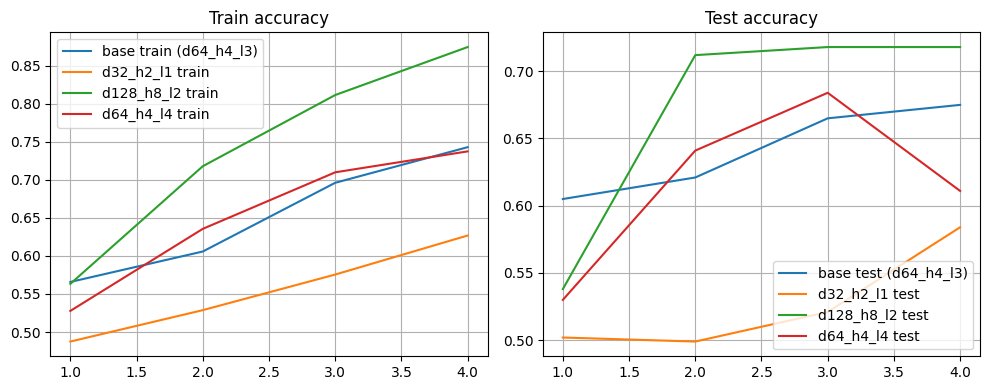

In [ ]:
def run_transformer_experiment(d_model, nhead, num_layers, num_epochs=4, label=""):
    m = TextTransformer(len(vocab), d_model, nhead, num_layers, num_classes=2).to(device)
    optimizer = torch.optim.Adam(m.parameters(), lr=3e-4)

    train_acc_hist, test_acc_hist = [], []
    import time
    total_time = 0

    for epoch in range(1, num_epochs + 1):
        m.train()
        epoch_correct, total_samples = 0, 0
        start = time.time()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            mask = (x == PAD_IDX).to(device)
            optimizer.zero_grad()
            logits = m(x, src_key_padding_mask=mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_samples += y.size(0)
        epoch_time = time.time() - start
        total_time += epoch_time

        m.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                mask = (x == PAD_IDX).to(device)
                logits = m(x, src_key_padding_mask=mask)
                val_correct += (logits.argmax(dim=-1) == y).sum().item()
                val_total += y.size(0)

        train_acc_hist.append(epoch_correct / total_samples)
        test_acc_hist.append(val_correct / val_total)
        print(f"[{label}] Эпоха {epoch}/{num_epochs} | "
              f"train_acc={train_acc_hist[-1]:.4f}, test_acc={test_acc_hist[-1]:.4f} | "
              f"время={epoch_time:.0f}с")

    print(f"[{label}] Общее время: {total_time:.0f}с, финальный test_acc={test_acc_hist[-1]:.4f}\n")
    return train_acc_hist, test_acc_hist

# Вариация 1: d_model=32, nhead=2, num_layers=1 - маленькая модель
ta1, ts1 = run_transformer_experiment(32, 2, 1, label="d32_h2_l1")

# Вариация 2: d_model=128, nhead=8, num_layers=2 - большая модель
ta2, ts2 = run_transformer_experiment(128, 8, 2, label="d128_h8_l2")

# Вариация 3: d_model=64, nhead=4, num_layers=4 - глубокая модель
ta3, ts3 = run_transformer_experiment(64, 4, 4, label="d64_h4_l4")

# График сравнения
epochs_arr = np.arange(1, 5)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_arr, train_acc, label="base train (d64_h4_l3)")
plt.plot(epochs_arr, ta1, label="d32_h2_l1 train")
plt.plot(epochs_arr, ta2, label="d128_h8_l2 train")
plt.plot(epochs_arr, ta3, label="d64_h4_l4 train")
plt.title("Train accuracy"); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_arr, test_acc, label="base test (d64_h4_l3)")
plt.plot(epochs_arr, ts1, label="d32_h2_l1 test")
plt.plot(epochs_arr, ts2, label="d128_h8_l2 test")
plt.plot(epochs_arr, ts3, label="d64_h4_l4 test")
plt.title("Test accuracy"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()
